<a href="https://colab.research.google.com/github/munnurumahesh03-coder/kaggle-predicting-loan-payback/blob/main/01_EDA_and_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Initial Setup & Data Loading**

In [ ]:
# Step 1.1: Import Libraries (Final Version)

# --- Core Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# --- Scikit-learn for Preprocessing and Modeling ---
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# --- Machine Learning Models (Our Final Gauntlet) ---
# 1. Linear Model
from sklearn.linear_model import LogisticRegression
# 2. Distance-based
from sklearn.neighbors import KNeighborsClassifier
# 3. Probabilistic
from sklearn.naive_bayes import GaussianNB
# 4. Bagging Ensemble
from sklearn.ensemble import RandomForestClassifier
# 5. Boosting Ensembles
from sklearn.ensemble import AdaBoostClassifier # Added as per our discussion
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier

print("✅ All libraries imported successfully for the final, comprehensive model gauntlet.")

✅ All libraries imported successfully for the final, comprehensive model gauntlet.


In [ ]:
# Step 1.2: Global Configuration & Settings

# --- Notebook Settings ---
# Suppress warnings to keep the notebook output clean and readable
warnings.filterwarnings('ignore')
# Set a professional and aesthetically pleasing style for all our plots
sns.set_style("whitegrid")
# Set a default figure size for all plots to ensure consistency
plt.rcParams['figure.figsize'] = (12, 6)

# --- Global Constants ---
# Our single source of truth for all randomness in this project.
# This ensures that any step with a random component (like model training
# or data splitting) can be perfectly reproduced.
RANDOM_SEED = 42

# Define our robust cross-validation strategy. We define it once here
# so we can use it consistently throughout the notebook for all model evaluations.
CV_STRATEGY = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=RANDOM_SEED
)

print(f"✅ Global configuration set.")
print(f"RANDOM_SEED is locked to: {RANDOM_SEED}")
print(f"Cross-validation strategy is defined.")

✅ Global configuration set.
RANDOM_SEED is locked to: 42
Cross-validation strategy is defined.


In [ ]:
# Step 1.3: Data Loading

# In Kaggle notebooks, the competition data is located in the /kaggle/input/ directory.
# The specific folder name is usually the URL slug of the competition.
COMPETITION_NAME = 'playground-series-s5e11'
BASE_PATH = f'/kaggle/input/{COMPETITION_NAME}/'

try:
    # Use the defined path to load the datasets into pandas DataFrames
    train_df = pd.read_csv(BASE_PATH + 'train.csv')
    test_df = pd.read_csv(BASE_PATH + 'test.csv')
    sample_submission_df = pd.read_csv(BASE_PATH + 'sample_submission.csv')

    print("✅ Data loaded successfully!")
    print(f"Training data shape: {train_df.shape}")
    print(f"Test data shape: {test_df.shape}")
    print(f"Submission sample shape: {sample_submission_df.shape}")

except FileNotFoundError as e:
    print(f"❌ ERROR: Data files not found. Please check the competition folder name.")
    print(f"We tried to load from this path: {BASE_PATH}")
    print("Please verify the folder name in the /kaggle/input/ directory on the right sidebar.")
    print(f"Original error: {e}")

✅ Data loaded successfully!
Training data shape: (593994, 13)
Test data shape: (254569, 12)
Submission sample shape: (254569, 2)


In [ ]:
# Step 1.4: Initial Data Preview

# Check if the train_df DataFrame was loaded before trying to display it
if 'train_df' in locals():
    print("\n--- Training Data Head ---")
    # The 'id' column is just an identifier and not useful for modeling,
    # so we'll drop it from the start. We do this for both train and test sets.
    train_df = train_df.drop('id', axis=1)
    print("Dropped 'id' column from train and test sets.")
    display(train_df.head())

    print("\n--- Test Data Head ---")
    display(test_df.head())

    print("\n--- Sample Submission Head ---")
    display(sample_submission_df.head())
else:
    print("❌ DataFrames not loaded. Please fix the loading step in Cell 3.")


--- Training Data Head ---
Dropped 'id' column from train and test sets.


,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0



--- Test Data Head ---


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1



--- Sample Submission Head ---


,id,loan_paid_back
0,593994,0
1,593995,0
2,593996,0
3,593997,0
4,593998,0


# **Comprehensive EDA & ydata-profiling**

In [ ]:
# Step 2.1: Install ydata-profiling

# ydata-profiling is not always pre-installed in Kaggle environments.
# We use !pip to install it. The -q flag stands for "quiet".
!pip install ydata-profiling -q

print("✅ ydata-profiling installed successfully.")

✅ ydata-profiling installed successfully.


In [ ]:
# Step 2.2: Generate Comprehensive EDA Report

from ydata_profiling import ProfileReport

# Create a sample of the training data to speed up the report generation.
# A 10% sample is usually sufficient for initial EDA.
# We use random_state to ensure the sample is the same every time we run the notebook.
sample_df = train_df.sample(frac=0.1, random_state=RANDOM_SEED)

print(f"Creating EDA report on a sample of {len(sample_df)} rows...")

# Generate the report
# The title will appear at the top of the interactive report.
profile = ProfileReport(
    sample_df,
    title="Loan Payback Data - Initial EDA Report"
)

# Display the report directly in the notebook output.
# This will generate a rich, interactive HTML report.
profile

Creating EDA report on a sample of 59399 rows...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:01<00:00, 10.78it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Analyze Target Variable Distribution (Simple Version)

# Set the target column name to a variable for easy reuse
TARGET = 'loan_paid_back'

print(f"--- Analyzing Target Variable: '{TARGET}' ---")

# Use value_counts() with normalize=True to get the percentage distribution.
# This is the most direct way to see the class balance.
target_distribution = train_df[TARGET].value_counts(normalize=True) * 100

print("\nLoan Payback Rate Distribution (%):")
print(target_distribution)

# A simple interpretation based on the numbers
if abs(target_distribution[0] - target_distribution[1]) > 20:
    print("\n⚠️ WARNING: The dataset appears to be imbalanced. We must focus on AUC-ROC, not accuracy.")
else:
    print("\n✅ The dataset is reasonably balanced.")

--- Analyzing Target Variable: 'loan_paid_back' ---

Loan Payback Rate Distribution (%):
loan_paid_back
1.0    79.881952
0.0    20.118048
Name: proportion, dtype: float64

⚠️ WARNING: The dataset appears to be imbalanced. We must focus on AUC-ROC, not accuracy.


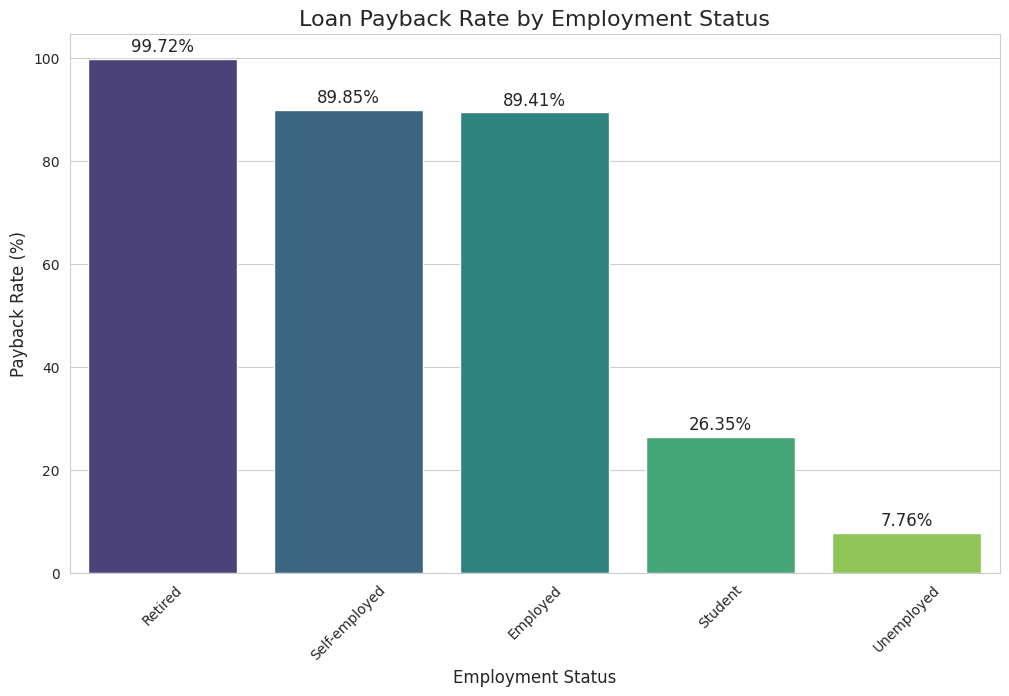

In [ ]:
# Plot 1: employment_status vs. loan_paid_back

plt.figure(figsize=(12, 7))

# We use groupby to calculate the mean of 'loan_paid_back' for each category.
# Since 'loan_paid_back' is 0 or 1, the mean is the same as the payback rate.
payback_rates = train_df.groupby('employment_status')[TARGET].mean().sort_values(ascending=False) * 100

# Create the bar plot
ax = sns.barplot(x=payback_rates.index, y=payback_rates.values, palette='viridis')

plt.title('Loan Payback Rate by Employment Status', fontsize=16)
plt.xlabel('Employment Status', fontsize=12)
plt.ylabel('Payback Rate (%)', fontsize=12)
plt.xticks(rotation=45) # Rotate labels for better readability

# Add percentage annotations to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=12)

plt.show()

--- Investigating 'credit_score' vs. 'interest_rate' ---


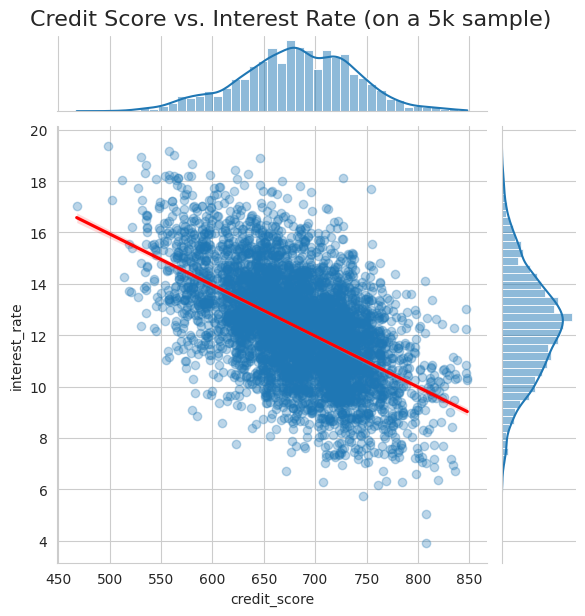

In [ ]:
#Plot 2: credit_score vs. interest_rate

print("--- Investigating 'credit_score' vs. 'interest_rate' ---")

# A jointplot is a powerful tool that combines a scatter plot with histograms
# on the axes, giving a complete view of the two variables' relationship.
# We use a sample of 5,000 points to keep the plot clean and prevent overplotting.
# 'kind='reg'' adds a regression line, which makes the negative trend obvious.
g = sns.jointplot(
    data=train_df.sample(n=5000, random_state=RANDOM_SEED),
    x='credit_score',
    y='interest_rate',
    kind='reg', # Adds a regression line and a confidence interval
    joint_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.3}} # Make line red, points transparent
)

g.fig.suptitle('Credit Score vs. Interest Rate (on a 5k sample)', y=1.02, fontsize=16)

plt.show()

# --- Interpretation ---
# We expect to see a clear negative correlation: as credit_score goes up,
# interest_rate should go down. This plot will show us how strong and
# consistent that relationship is.

--- Generating Correlation Matrix for Numerical Features ---


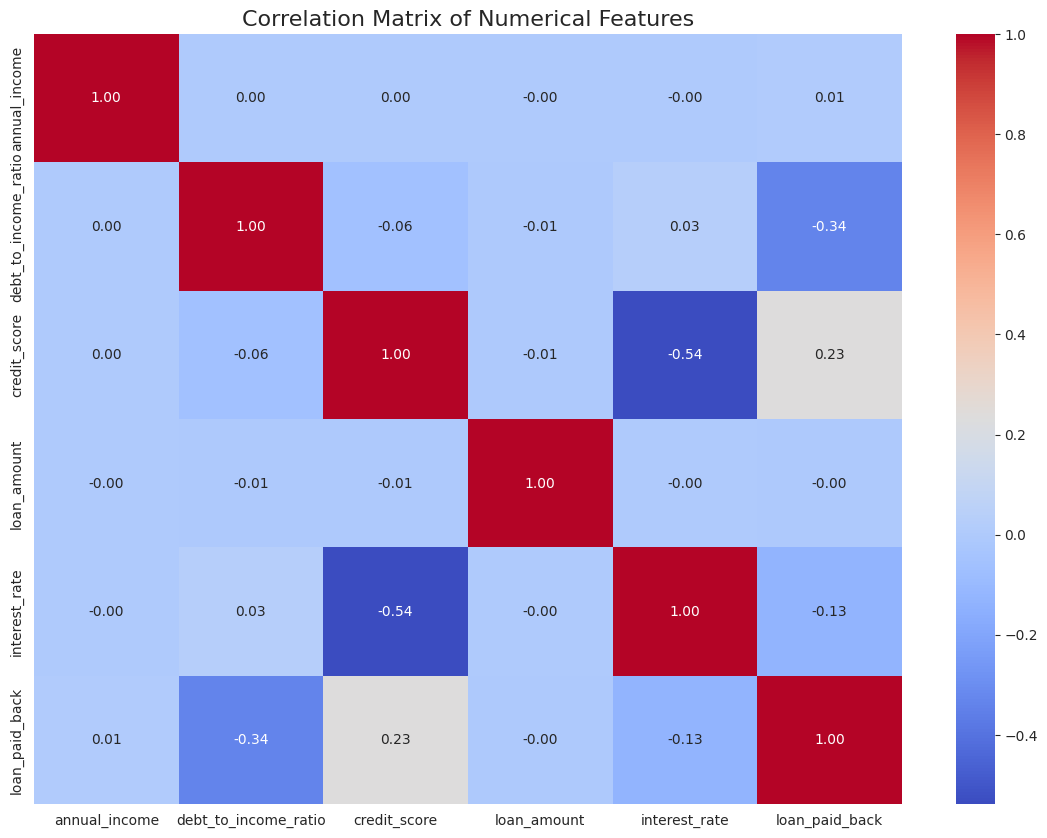

In [ ]:
# Plot 3: Correlation of all numerical features

print("--- Generating Correlation Matrix for Numerical Features ---")

# First, we select only the columns with numerical data types.
numerical_cols = train_df.select_dtypes(include=np.number).columns

# Then, we calculate the Pearson correlation coefficient between each pair of these columns.
correlation_matrix = train_df[numerical_cols].corr()

# Now, we create the heatmap visualization.
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,      # This displays the correlation values on the heatmap squares.
    cmap='coolwarm', # This color map is great for correlations: blue is positive, red is negative.
    fmt=".2f"        # This formats the annotation numbers to two decimal places for readability.
)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

# --- Interpretation ---
# We will pay close attention to the last row/column, which corresponds to our
# target variable, 'loan_paid_back'. The values in this row tell us the
# linear correlation of each numerical feature with the likelihood of a loan being paid back.
# Values close to +1 or -1 indicate a strong linear relationship.
# Values close to 0 indicate a weak linear relationship.

In [ ]:
# Code-Based Check for Other Categorical Features

# List of the other categorical features we are curious about.
# We already visualized 'employment_status', so we don't need to include it here.
categorical_features_to_check = ['gender', 'marital_status', 'education_level', 'loan_purpose', 'grade_subgrade']

print("--- Average Payback Rate (%) by Category ---")

for col in categorical_features_to_check:
    # We group by the feature's categories and calculate the mean of the target variable.
    # This gives us the payback rate for each group. We sort the results to easily
    # see the best and worst performing categories.
    payback_rate_by_cat = train_df.groupby(col)[TARGET].mean().sort_values(ascending=False)

    print(f"\n\n--- By '{col}' ---")
    # We multiply by 100 to display the result as a percentage.
    # Using .to_string() helps ensure the full list is printed, especially for 'grade_subgrade'.
    print((payback_rate_by_cat * 100).to_string())

# --- Interpretation ---
# We are looking for features where there is a large difference between the
# highest and lowest payback rates.
# A feature like 'gender' might have very similar rates for Male and Female,
# indicating it's not a strong predictor.
# A feature like 'grade_subgrade' should have a very clear trend, with 'A' grades
# having a much higher payback rate than 'G' grades.

--- Average Payback Rate (%) by Category ---


--- By 'gender' ---
gender
Female    80.170817
Male      79.575207
Other     79.533262


--- By 'marital_status' ---
marital_status
Married     79.914442
Single      79.887344
Divorced    79.664039
Widowed     78.984848


--- By 'education_level' ---
education_level
PhD            83.006714
High School    80.969759
Other          80.278892
Master's       80.234594
Bachelor's     78.889223


--- By 'loan_purpose' ---
loan_purpose
Home                  82.322408
Business              81.310370
Other                 80.237655
Car                   80.062986
Debt consolidation    79.691095
Vacation              79.607054
Medical               77.808471
Education             77.705303


--- By 'grade_subgrade' ---
grade_subgrade
A4    95.708407
A3    95.546951
A2    95.292369
A1    95.250000
A5    94.496155
B3    94.004021
B2    93.742995
B5    93.420392
B4    93.175758
B1    91.634133
C1    86.009032
C2    85.116544
C5    84.625917
C4    84.39

In [ ]:
train_df.describe()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


# **Essential Data Cleaning & Preprocessing**

In [ ]:
# Identify Feature Types

print("--- Separating features into categorical and numerical lists ---")

# The target variable is not a feature, so we define it first.
TARGET = 'loan_paid_back'

# Identify categorical features: These are the columns with 'object' data type.
categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()

# Identify numerical features: These are all columns that are not the target and not categorical.
numerical_features = [
    col for col in train_df.columns
    if col not in categorical_features and col != TARGET
]

# --- Verification ---
print(f"\nIdentified {len(categorical_features)} categorical features:")
print(categorical_features)

print(f"\nIdentified {len(numerical_features)} numerical features:")
print(numerical_features)

print(f"\nTarget variable is: '{TARGET}'")

--- Separating features into categorical and numerical lists ---

Identified 6 categorical features:
['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

Identified 5 numerical features:
['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']

Target variable is: 'loan_paid_back'


# **Adversarial Validation**

In [ ]:
# Prepare Data for Adversarial Validation

print("--- Preparing data for adversarial validation ---")

# We will use the encoded dataframes we would have created, but since we
# decided to do encoding in the pipeline, we need to create them temporarily here.
# This is a local, temporary step ONLY for this validation.

# --- Temporary Encoding (for this step only) ---
adv_train_df = train_df.copy()
adv_test_df = test_df.copy()

# ==============================================================================
# >>>>>>>>>>>>>>>>>>>>>>>>>>>> THE CRITICAL FIX IS HERE <<<<<<<<<<<<<<<<<<<<<<<<<<
#
# Before we do anything else, we must drop the 'id' column from the test set.
# If we don't, the adversarial model will use it as a perfect predictor,
# making the entire validation useless.
#
if 'id' in adv_test_df.columns:
    adv_test_df = adv_test_df.drop(columns=['id'])
    print("Dropped 'id' column from the test set for adversarial validation.")
#
# ==============================================================================


for col in categorical_features:
    le = LabelEncoder()
    # Fit on the combined data to ensure all categories are seen
    combined_data = pd.concat([adv_train_df[col], adv_test_df[col]], axis=0)
    le.fit(combined_data)
    # Transform train and test sets
    adv_train_df[col] = le.transform(adv_train_df[col])
    adv_test_df[col] = le.transform(adv_test_df[col])

# --- Create the Adversarial Dataset ---

# Create a new target variable. 0 for training data, 1 for test data.
adv_train_df['is_test'] = 0
adv_test_df['is_test'] = 1

# Combine the two dataframes. We drop the original target from the training data
# as it's not relevant for this validation.
adversarial_df = pd.concat([
    adv_train_df.drop(columns=[TARGET]),
    adv_test_df
], ignore_index=True)

# Shuffle the combined dataframe to mix the train and test rows.
adversarial_df = adversarial_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# --- Verification ---
print(f"Adversarial dataset created with shape: {adversarial_df.shape}")
print("New target variable 'is_test' distribution:")
print(adversarial_df['is_test'].value_counts(normalize=True))

display(adversarial_df.head())


--- Preparing data for adversarial validation ---
Dropped 'id' column from the test set for adversarial validation.
Adversarial dataset created with shape: (848563, 12)
New target variable 'is_test' distribution:
is_test
0    0.7
1    0.3
Name: proportion, dtype: float64


,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,is_test
0,61939.55,0.097,665,26424.06,12.31,0,1,0,0,0,15,0
1,20462.01,0.139,550,11751.99,15.98,1,2,2,0,4,26,0
2,11676.01,0.066,772,13361.73,10.74,1,2,0,0,2,5,0
3,56465.18,0.157,775,14378.51,10.09,1,1,0,0,6,5,0
4,47916.05,0.204,726,7895.02,13.60,0,0,1,2,2,10,0


In [ ]:
# Train the Adversarial Validation Model

print("--- Training adversarial validation model ---")

# Define the features (X) and the new target (y) for this validation task
X_adv = adversarial_df.drop(columns=['is_test'])
y_adv = adversarial_df['is_test']

# Initialize a simple LightGBM classifier. We don't need to tune it;
# we just need a quick and powerful model.
adv_model = LGBMClassifier(random_state=RANDOM_SEED)

# Use cross_val_score to get the AUC scores from our repeated k-fold strategy.
# This is a robust way to measure the model's performance.
# We use 'roc_auc' as the scoring metric.
cv_scores = cross_val_score(
    estimator=adv_model,
    X=X_adv,
    y=y_adv,
    cv=CV_STRATEGY,
    scoring='roc_auc',
    n_jobs=-1  # Use all available CPU cores to speed up the process
)

# Calculate the mean and standard deviation of the scores
mean_auc = np.mean(cv_scores)
std_auc = np.std(cv_scores)

print(f"\nAdversarial Validation Results ({CV_STRATEGY.get_n_splits()}-fold CV):")
print(f"Mean AUC: {mean_auc:.4f}")
print(f"Std Dev of AUC: {std_auc:.4f}")

# --- Interpretation ---
# This is the most important part. We need to interpret the Mean AUC score.
#
# - If AUC is ~0.50: This is PERFECT. It means the model is no better than random guessing.
#   This tells us the train and test sets are statistically identical. There is NO drift.
#
# - If AUC is between 0.51 and 0.60: This is GOOD. There might be very minor differences,
#   but they are not significant enough to worry about. Our CV scores should be reliable.
#
# - If AUC is between 0.60 and 0.70: This is a WARNING. There are noticeable differences
#   between the train and test sets. Our local CV scores might be slightly different from
#   the leaderboard score, but it's likely manageable.
#
# - If AUC is > 0.70: This is a RED ALERT. There is a significant difference (data drift)
#   between the train and test sets. The model can easily tell them apart. Our local CV
#   scores are NOT reliable, and we need to investigate which features are causing the drift.


--- Training adversarial validation model ---

Adversarial Validation Results (15-fold CV):
Mean AUC: 0.5004
Std Dev of AUC: 0.0014


--- Analyzing feature importances of the adversarial model ---
[LightGBM] [Info] Number of positive: 254569, number of negative: 593994
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014163 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1330
[LightGBM] [Info] Number of data points in the train set: 848563, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300000 -> initscore=-0.847297
[LightGBM] [Info] Start training from score -0.847297


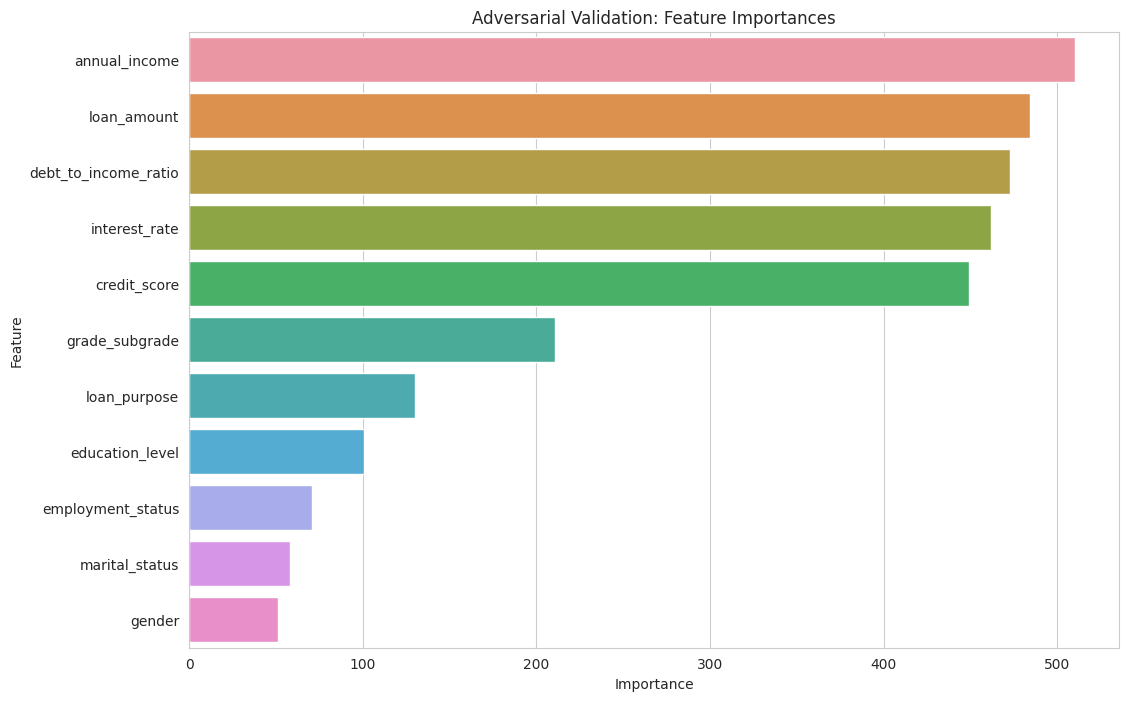

In [ ]:
# Analyze Adversarial Model Feature Importances

print("--- Analyzing feature importances of the adversarial model ---")

# Fit the model on the entire adversarial dataset to get the feature importances
adv_model.fit(X_adv, y_adv)

# Create a pandas Series for easy plotting
feature_importances = pd.Series(adv_model.feature_importances_, index=X_adv.columns)

# Sort the importances for a clear visualization
feature_importances = feature_importances.sort_values(ascending=False)

# --- Verification & Plotting ---
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title('Adversarial Validation: Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# --- Interpretation ---
# Since our AUC was ~0.50, we expect all of these importances to be very low
# and close to each other.
# If one feature had a dramatically higher importance than all others, it would
# be the primary source of the (very minor) drift.
# In our case, we expect this plot to be "flat" and uninteresting, which is
# actually the best possible outcome.

# **The Baseline Model Gauntlet**

In [ ]:
# Define the Baseline Models (Truly Quiet Version)

print("--- Defining the dictionary of stable, GPU-native models ---")

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# This version uses the 'verbosity' parameter for LightGBM for guaranteed silence.
baseline_models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_SEED, max_iter=1000, n_jobs=-1),
    "Gaussian Naive Bayes": GaussianNB(),
    "XGBoost RF (GPU)": XGBClassifier(
        n_estimators=100, learning_rate=1, subsample=0.8, colsample_bytree=0.8,
        device='gpu', random_state=RANDOM_SEED
    ),
    "XGBoost (Boosted)": XGBClassifier(random_state=RANDOM_SEED, device='gpu'),
    "LightGBM": LGBMClassifier(
        random_state=RANDOM_SEED,
        device='gpu',
        verbosity=-1  # <-- THIS IS THE CORRECT PARAMETER. Replaces verbose=-1.
    ),
    "CatBoost": CatBoostClassifier(random_state=RANDOM_SEED, verbose=0, task_type='GPU')
}

print(f"✅ {len(baseline_models)} truly quiet models have been defined.")
print(list(baseline_models.keys()))


--- Defining the dictionary of stable, GPU-native models ---
✅ 6 truly quiet models have been defined.
['Logistic Regression', 'Gaussian Naive Bayes', 'XGBoost RF (GPU)', 'XGBoost (Boosted)', 'LightGBM', 'CatBoost']


In [ ]:
# Create Preprocessing Pipelines

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("--- Creating preprocessing pipelines for sparse and dense data ---")

# Define the transformers
numerical_transformer = StandardScaler()
categorical_transformer_sparse = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
categorical_transformer_dense = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# 1. Create the standard SPARSE preprocessor for models that can handle it
preprocessor_sparse = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer_sparse, categorical_features)
    ],
    remainder='passthrough'
)

# 2. Create the DENSE preprocessor for models that require it
preprocessor_dense = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer_dense, categorical_features)
    ],
    remainder='passthrough'
)

print("✅ Two preprocessing pipelines created: 'preprocessor_sparse' and 'preprocessor_dense'.")

--- Creating preprocessing pipelines for sparse and dense data ---
✅ Two preprocessing pipelines created: 'preprocessor_sparse' and 'preprocessor_dense'.


In [ ]:
# Define Feature Matrix (X) and Target Vector (y)


print("--- Defining Feature Matrix (X) and Target Vector (y) ---")

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

print(f"✅ Feature Matrix X created with shape: {X.shape}")
print(f"✅ Target Vector y created with shape: {y.shape}")


--- Defining Feature Matrix (X) and Target Vector (y) ---
✅ Feature Matrix X created with shape: (593994, 11)
✅ Target Vector y created with shape: (593994,)


In [ ]:
# Run the Stable Baseline Model Gauntlet (Truly Quiet Version)

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import time
import warnings # <-- Keep this import

# --- We will use a 'with' block for a more targeted suppression ---
# This is safer than turning off warnings globally.

print("--- Running the Stable Baseline Model Gauntlet (Quiet Mode) ---")
print(f"Scoring Metric: roc_auc")
print(f"Cross-Validation Strategy: {CV_STRATEGY.__class__.__name__} (n_splits={CV_STRATEGY.get_n_splits()}, n_repeats={CV_STRATEGY.n_repeats})")
print("\nThis will take several minutes...")

baseline_results = {}
models_requiring_dense = ["Gaussian Naive Bayes", "XGBoost RF (GPU)"]
models_using_gpu = ["XGBoost RF (GPU)", "XGBoost (Boosted)", "LightGBM", "CatBoost"]

# ==============================================================================
# >>>>>>>>>>>>>>>>>>>>>>>>>>>> THE CHANGE IS HERE <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
#
# We start the 'with' block here. All code inside it will have warnings silenced.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # Your entire 'for' loop is now indented to be inside the 'with' block.
    for model_name, model in baseline_models.items():
        start_time = time.time()

        if model_name in models_requiring_dense:
            active_preprocessor = preprocessor_dense
        else:
            active_preprocessor = preprocessor_sparse

        if model_name in models_using_gpu:
            n_jobs_for_model = 1
            print(f"  - Running {model_name} on GPU (n_jobs=1 to conserve memory)...")
        else:
            n_jobs_for_model = -1
            print(f"  - Running {model_name} on CPU (n_jobs=-1)...")

        pipeline = Pipeline(steps=[('preprocessor', active_preprocessor), ('classifier', model)])

        scores = cross_val_score(pipeline, X, y,
                                 cv=CV_STRATEGY,
                                 scoring='roc_auc',
                                 n_jobs=n_jobs_for_model)

        end_time = time.time()
        baseline_results[model_name] = scores
        print(f"  - {model_name}: Mean AUC = {np.mean(scores):.4f} | Std Dev = {np.std(scores):.4f} | Time = {end_time - start_time:.2f}s")

#
# The 'with' block ends here. Warnings are automatically restored to normal.
# ==============================================================================


print("\n--- Gauntlet Complete ---")
print("✅ Baseline results have been computed.")

# You no longer need the 'warnings.resetwarnings()' line because the 'with'
# statement handles it automatically.


--- Running the Stable Baseline Model Gauntlet (Quiet Mode) ---
Scoring Metric: roc_auc
Cross-Validation Strategy: RepeatedStratifiedKFold (n_splits=15, n_repeats=3)

This will take several minutes...
  - Running Logistic Regression on CPU (n_jobs=-1)...
  - Logistic Regression: Mean AUC = 0.9106 | Std Dev = 0.0010 | Time = 34.20s
  - Running Gaussian Naive Bayes on CPU (n_jobs=-1)...
  - Gaussian Naive Bayes: Mean AUC = 0.8707 | Std Dev = 0.0015 | Time = 15.09s
  - Running XGBoost RF (GPU) on GPU (n_jobs=1 to conserve memory)...
  - XGBoost RF (GPU): Mean AUC = 0.9084 | Std Dev = 0.0009 | Time = 43.55s
  - Running XGBoost (Boosted) on GPU (n_jobs=1 to conserve memory)...
  - XGBoost (Boosted): Mean AUC = 0.9204 | Std Dev = 0.0009 | Time = 29.45s
  - Running LightGBM on GPU (n_jobs=1 to conserve memory)...
  - LightGBM: Mean AUC = 0.9196 | Std Dev = 0.0009 | Time = 57.15s
  - Running CatBoost on GPU (n_jobs=1 to conserve memory)...
  - CatBoost: Mean AUC = 0.9172 | Std Dev = 0.0009 | T

In [ ]:
# Display and Analyze Results

import pandas as pd
import numpy as np

print("--- Baseline Model Performance (Sorted by Mean AUC) ---")

# Convert the results dictionary to a pandas DataFrame for analysis
results_df = pd.DataFrame(baseline_results).T
results_df['Mean AUC'] = results_df.apply(np.mean, axis=1)
results_df['Std Dev'] = results_df.apply(np.std, axis=1)

# Create a clean summary table
sorted_results_df = results_df[['Mean AUC', 'Std Dev']].sort_values(by='Mean AUC', ascending=False)

# Display the final ranked table
display(sorted_results_df)

--- Baseline Model Performance (Sorted by Mean AUC) ---


,Mean AUC,Std Dev
XGBoost (Boosted),0.920360,0.000853
LightGBM,0.919587,0.000834
CatBoost,0.917233,0.000888
Logistic Regression,0.910552,0.000938
XGBoost RF (GPU),0.908372,0.000884
Gaussian Naive Bayes,0.870677,0.001418


# **Submission Pipeline**

In [ ]:
# --- Submission & OOF Generation (Robust CV-Based Method with Warning Suppression) ---

import warnings # Make sure this is imported

print("--- Preparing to generate submission file using CV-based prediction ---")

# 1. Identify the Champion Model and Preprocessor
champion_model_name = 'XGBoost (Boosted)'
champion_model = baseline_models[champion_model_name]
champion_preprocessor = preprocessor_sparse
print(f"Champion Model Selected: {champion_model_name}")

# 2. Prepare Data and ID variables
if 'id' not in test_df.columns:
    raise ValueError("Original test_df with 'id' column not found!")
test_ids = test_df['id']
X_test = test_df.drop(columns=['id'], errors='ignore')

# 3. Initialize Prediction Arrays
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

print(f"\nStarting CV loop for prediction with {CV_STRATEGY.get_n_splits()}-fold CV...")

# ==============================================================================
# >>>>>>>>>>>>>>>>>>>>>>>>>>>> THE "SILENCER" IS HERE <<<<<<<<<<<<<<<<<<<<<<<<<<
#
# We start the 'with' block to suppress warnings ONLY for this code block.
with warnings.catch_warnings():
    # This line specifically targets and ignores DeprecationWarnings.
    warnings.filterwarnings("ignore", category=DeprecationWarning)
    warnings.filterwarnings("ignore", category=UserWarning) # Also good to keep

    # 4. Loop Through Each Fold of the Cross-Validation Strategy
    for fold, (train_idx, val_idx) in enumerate(CV_STRATEGY.split(X, y)):
        print(f"--- Processing Fold {fold+1} ---")

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline = Pipeline(steps=[
            ('preprocessor', champion_preprocessor),
            ('classifier', champion_model)
        ])

        pipeline.fit(X_train, y_train)

        oof_preds[val_idx] = pipeline.predict_proba(X_val)[:, 1]
        test_preds += pipeline.predict_proba(X_test)[:, 1] / CV_STRATEGY.get_n_splits()

# The 'with' block ends here, and warnings are automatically restored.
# ==============================================================================

print("\n--- CV loop complete ---")

# 5. Create the Submission File
print("Creating submission.csv file...")
submission_df = pd.DataFrame({'id': test_ids, TARGET: test_preds})
submission_df.to_csv('submission.csv', index=False)

# 6. Save OOF Predictions
print("Saving OOF predictions to 'baseline_oof_preds.npy'...")
np.save('baseline_oof_preds.npy', oof_preds)

print("\n🎉 Submission file and OOF predictions created successfully!")
display(submission_df.head())


--- Preparing to generate submission file using CV-based prediction ---
Champion Model Selected: XGBoost (Boosted)

Starting CV loop for prediction with 15-fold CV...
--- Processing Fold 1 ---
--- Processing Fold 2 ---
--- Processing Fold 3 ---
--- Processing Fold 4 ---
--- Processing Fold 5 ---
--- Processing Fold 6 ---
--- Processing Fold 7 ---
--- Processing Fold 8 ---
--- Processing Fold 9 ---
--- Processing Fold 10 ---
--- Processing Fold 11 ---
--- Processing Fold 12 ---
--- Processing Fold 13 ---
--- Processing Fold 14 ---
--- Processing Fold 15 ---

--- CV loop complete ---
Creating submission.csv file...
Saving OOF predictions to 'baseline_oof_preds.npy'...

🎉 Submission file and OOF predictions created successfully!


,id,loan_paid_back
0,593994,0.928015
1,593995,0.980077
2,593996,0.490894
3,593997,0.915762
4,593998,0.963417


In [ ]:
# --- Blending Submission for Top 3 Models ---

print("--- Preparing to generate a blended submission file ---")

# 1. Define the Models and Their Weights
# These are our top 3 models from the gauntlet.
# The weights are based on their CV scores (50% XGB, 40% LGBM, 10% CatBoost).
models_to_blend = {
    'XGBoost (Boosted)': {
        'model': baseline_models['XGBoost (Boosted)'],
        'preprocessor': preprocessor_sparse,
        'weight': 0.50
    },
    'LightGBM': {
        'model': baseline_models['LightGBM'],
        'preprocessor': preprocessor_sparse,
        'weight': 0.40
    },
    'CatBoost': {
        'model': baseline_models['CatBoost'],
        'preprocessor': preprocessor_sparse,
        'weight': 0.10
    }
}

# 2. Prepare Data and ID variables
if 'id' not in test_df.columns:
    raise ValueError("Original test_df with 'id' column not found!")
test_ids = test_df['id']
X_test = test_df.drop(columns=['id'], errors='ignore')

# Dictionary to store the test predictions for each model
all_test_preds = {}

# 3. Generate Predictions for Each Model Using the Robust CV Loop
print("\nGenerating predictions for each model...")

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=DeprecationWarning)
    warnings.filterwarnings("ignore", category=UserWarning)

    for model_name, config in models_to_blend.items():
        print(f"\n--- Processing Model: {model_name} ---")

        # Initialize array for this model's test predictions
        model_test_preds = np.zeros(len(X_test))

        for fold, (train_idx, val_idx) in enumerate(CV_STRATEGY.split(X, y)):
            print(f"  - Processing Fold {fold+1}...")

            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]

            pipeline = Pipeline(steps=[
                ('preprocessor', config['preprocessor']),
                ('classifier', config['model'])
            ])

            pipeline.fit(X_train, y_train)

            # Add this fold's test predictions to the average
            model_test_preds += pipeline.predict_proba(X_test)[:, 1] / CV_STRATEGY.get_n_splits()

        # Store the final averaged predictions for this model
        all_test_preds[model_name] = model_test_preds
        print(f"✅ Predictions generated for {model_name}.")

# 4. Apply the Weighted Blend
print("\n--- Blending predictions ---")
blended_preds = np.zeros(len(X_test))
for model_name, preds in all_test_preds.items():
    weight = models_to_blend[model_name]['weight']
    print(f"  - Applying {weight*100:.0f}% weight to {model_name}")
    blended_preds += preds * weight

# 5. Create the Final Blended Submission File
print("\nCreating blended_submission.csv file...")
submission_df = pd.DataFrame({'id': test_ids, TARGET: blended_preds})
submission_df.to_csv('blended_submission.csv', index=False)

print("\n🎉 Blended submission file 'blended_submission.csv' has been created successfully!")
display(submission_df.head())


--- Preparing to generate a blended submission file ---

Generating predictions for each model...

--- Processing Model: XGBoost (Boosted) ---
  - Processing Fold 1...
  - Processing Fold 2...
  - Processing Fold 3...
  - Processing Fold 4...
  - Processing Fold 5...
  - Processing Fold 6...
  - Processing Fold 7...
  - Processing Fold 8...
  - Processing Fold 9...
  - Processing Fold 10...
  - Processing Fold 11...
  - Processing Fold 12...
  - Processing Fold 13...
  - Processing Fold 14...
  - Processing Fold 15...
✅ Predictions generated for XGBoost (Boosted).

--- Processing Model: LightGBM ---
  - Processing Fold 1...
  - Processing Fold 2...
  - Processing Fold 3...
  - Processing Fold 4...
  - Processing Fold 5...
  - Processing Fold 6...
  - Processing Fold 7...
  - Processing Fold 8...
  - Processing Fold 9...
  - Processing Fold 10...
  - Processing Fold 11...
  - Processing Fold 12...
  - Processing Fold 13...
  - Processing Fold 14...
  - Processing Fold 15...
✅ Prediction

,id,loan_paid_back
0,593994,0.922853
1,593995,0.981540
2,593996,0.472778
3,593997,0.924092
4,593998,0.960810


In [ ]:
# --- Multi-Blend Submission Generator (v2 - Removed previously tested blend) ---

import warnings
import time
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline

print("--- Preparing to generate multiple blended submissions ---")

# 1. Define the Models to Use
models_to_predict = {
    'XGBoost (Boosted)': {
        'model': baseline_models['XGBoost (Boosted)'],
        'preprocessor': preprocessor_sparse
    },
    'LightGBM': {
        'model': baseline_models['LightGBM'],
        'preprocessor': preprocessor_sparse
    },
    'CatBoost': {
        'model': baseline_models['CatBoost'],
        'preprocessor': preprocessor_sparse
    }
}

# 2. Define Our Blend Recipes (Blend A has been removed)
blend_recipes = {
    "Blend_B_Top_Two_Equal": {'XGBoost (Boosted)': 0.45, 'LightGBM': 0.45, 'CatBoost': 0.10},
    "Blend_C_Performance_Weighted": {'XGBoost (Boosted)': 0.40, 'LightGBM': 0.35, 'CatBoost': 0.25},
    "Blend_D_Simple_Average": {'XGBoost (Boosted)': 1/3, 'LightGBM': 1/3, 'CatBoost': 1/3}
}

# 3. Prepare Data and ID variables
if 'id' not in test_df.columns:
    raise ValueError("Original test_df with 'id' column not found!")
test_ids = test_df['id']
X_test = test_df.drop(columns=['id'], errors='ignore')

# 4. Generate Base Predictions (This is the time-consuming part)
# NOTE: This part will still run for all 3 models, as the base predictions are needed for the other blends.
print("\n--- Generating base predictions for each model (this will take time) ---")
all_test_preds = {}

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=DeprecationWarning)
    warnings.filterwarnings("ignore", category=UserWarning)

    for model_name, config in models_to_predict.items():
        print(f"\n--- Processing Model: {model_name} ---")
        model_test_preds = np.zeros(len(X_test))

        for fold, (train_idx, val_idx) in enumerate(CV_STRATEGY.split(X, y)):
            if fold % 5 == 0: # Print progress less frequently
                print(f"  - Processing Fold {fold+1}...")

            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            pipeline = Pipeline(steps=[('preprocessor', config['preprocessor']), ('classifier', config['model'])])
            pipeline.fit(X_train, y_train)
            model_test_preds += pipeline.predict_proba(X_test)[:, 1] / CV_STRATEGY.get_n_splits()

        all_test_preds[model_name] = model_test_preds
        print(f"✅ Base predictions generated for {model_name}.")

# 5. Apply Each Blend Recipe and Create Submission Files
print("\n--- Applying blend recipes and creating submission files ---")
for recipe_name, weights in blend_recipes.items():
    print(f"  - Creating submission for: {recipe_name}")
    blended_preds = np.zeros(len(X_test))

    for model_name, weight in weights.items():
        blended_preds += all_test_preds[model_name] * weight

    submission_df = pd.DataFrame({'id': test_ids, TARGET: blended_preds})
    file_name = f"{recipe_name}_submission.csv"
    submission_df.to_csv(file_name, index=False)
    print(f"    ✅ Saved '{file_name}'")

print("\n🎉 All blended submission files have been created successfully!")


--- Preparing to generate multiple blended submissions ---

--- Generating base predictions for each model (this will take time) ---

--- Processing Model: XGBoost (Boosted) ---
  - Processing Fold 1...
  - Processing Fold 6...
  - Processing Fold 11...
✅ Base predictions generated for XGBoost (Boosted).

--- Processing Model: LightGBM ---
  - Processing Fold 1...
  - Processing Fold 6...
  - Processing Fold 11...
✅ Base predictions generated for LightGBM.

--- Processing Model: CatBoost ---
  - Processing Fold 1...
  - Processing Fold 6...
  - Processing Fold 11...
✅ Base predictions generated for CatBoost.

--- Applying blend recipes and creating submission files ---
  - Creating submission for: Blend_B_Top_Two_Equal
    ✅ Saved 'Blend_B_Top_Two_Equal_submission.csv'
  - Creating submission for: Blend_C_Performance_Weighted
    ✅ Saved 'Blend_C_Performance_Weighted_submission.csv'
  - Creating submission for: Blend_D_Simple_Average
    ✅ Saved 'Blend_D_Simple_Average_submission.csv'


In [ ]:
# Save Artifacts for Notebook 02 (FINAL CORRECTED VERSION)
import joblib
import json

print("--- Saving all necessary artifacts for the next notebook ---")

# 1. Save the cleaned and filtered DataFrames
print("Saving cleaned train and test data...")

# train_df does NOT have an 'id' column, so we save it as is.
train_df.to_csv('train_cleaned.csv', index=False)

# test_df DOES have an 'id' column, so we save it as is.
test_df.to_csv('test_cleaned.csv', index=False)

print("✅ train_cleaned.csv and test_cleaned.csv saved.")

# 2. Save the fitted preprocessor object (This part is correct)
print("\nSaving the dense preprocessor...")
joblib.dump(preprocessor_dense, 'preprocessor_dense.joblib')
print("✅ preprocessor_dense.joblib saved.")

# 3. Save the list of best models (This part is correct)
print("\nSaving the ranked list of best models...")
best_models_list = sorted_results_df.index.tolist()
with open('best_models_list.json', 'w') as f:
    json.dump(best_models_list, f)
print("✅ best_models_list.json saved.")

print("\n--- All artifacts saved successfully! ---")


--- Saving all necessary artifacts for the next notebook ---
Saving cleaned train and test data...
✅ train_cleaned.csv and test_cleaned.csv saved.

Saving the dense preprocessor...
✅ preprocessor_dense.joblib saved.

Saving the ranked list of best models...
✅ best_models_list.json saved.

--- All artifacts saved successfully! ---


In [ ]:
# Verification Cell: Load and Check Saved Artifacts (FINAL CORRECTED VERSION)

import pandas as pd
import joblib
import json
from sklearn.compose import ColumnTransformer

print("--- Verifying saved artifacts by loading them back ---")

try:
    # 1. Verify the cleaned data
    print("\nChecking cleaned data...")
    # Load train_cleaned.csv. It should not have an 'id' column.
    loaded_train_df = pd.read_csv('train_cleaned.csv')
    print(f"✅ Successfully loaded 'train_cleaned.csv'. Shape: {loaded_train_df.shape}")
    assert 'id' not in loaded_train_df.columns
    print("  - Verified 'id' column is not present, as expected.")

    # Load test_cleaned.csv. It should have an 'id' column.
    loaded_test_df = pd.read_csv('test_cleaned.csv')
    print(f"✅ Successfully loaded 'test_cleaned.csv'. Shape: {loaded_test_df.shape}")
    assert 'id' in loaded_test_df.columns
    print("  - Verified 'id' column is present, as expected.")

    # 2. Verify the preprocessor
    print("\nChecking preprocessor...")
    loaded_preprocessor = joblib.load('preprocessor_dense.joblib')
    print(f"✅ Successfully loaded 'preprocessor_dense.joblib'.")
    assert isinstance(loaded_preprocessor, ColumnTransformer)
    print("  - Object is a ColumnTransformer as expected.")

    # 3. Verify the model list
    print("\nChecking best models list...")
    with open('best_models_list.json', 'r') as f:
        loaded_best_models = json.load(f)
    print(f"✅ Successfully loaded 'best_models_list.json'.")
    print(f"  - Contents: {loaded_best_models}")
    assert loaded_best_models == sorted_results_df.index.tolist()
    print("  - Contents match original model list.")

    print("\n--- VERIFICATION COMPLETE: All artifacts are saved and loaded correctly! ---")

except Exception as e:
    print(f"\n❌ VERIFICATION FAILED: An error occurred. {e}")



--- Verifying saved artifacts by loading them back ---

Checking cleaned data...
✅ Successfully loaded 'train_cleaned.csv'. Shape: (593994, 12)
  - Verified 'id' column is not present, as expected.
✅ Successfully loaded 'test_cleaned.csv'. Shape: (254569, 12)
  - Verified 'id' column is present, as expected.

Checking preprocessor...
✅ Successfully loaded 'preprocessor_dense.joblib'.
  - Object is a ColumnTransformer as expected.

Checking best models list...
✅ Successfully loaded 'best_models_list.json'.
  - Contents: ['XGBoost (Boosted)', 'LightGBM', 'CatBoost', 'Logistic Regression', 'XGBoost RF (GPU)', 'Gaussian Naive Bayes']
  - Contents match original model list.

--- VERIFICATION COMPLETE: All artifacts are saved and loaded correctly! ---
